# Functions and Visualizations

This week, we'll learn about functions, table methods such as `apply`, and how to generate visualizations! 



First, set up the notebook by running the cell below.

In [2]:
import numpy as np
from datascience import *

# These lines set up graphing capabilities.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


## Defining functions

### A function is a reusable piece of code that can accept input parameters, also known as “arguments”. 

For example, let’s define a function called double which takes one input parameter n and returns the square n**2:


A function definition has a few parts.

<img src="function_definition.jpg" alt="drawing" width="500"/>


## The Anatomy of a Function ##  
    
```python
def functionname(Arguments_Parameters_Expressions_or_Values):     
      return return_expression
```

##### `def`
It always starts with `def` (short for **def**ine):

    def

##### Name
Next comes the name of the function.  Like other names we've defined, it can't start with a number or contain spaces. Let's call our function `double`:
    
    def double

##### Signature
Next comes something called the *signature* of the function.  This tells Python how many arguments your function should have, and what names you'll use to refer to those arguments in the function's code.  A function can have any number of arguments (including 0!). 

`double` should take one argument, and we'll call that argument `n` since it should be a number.

    def double(n)
    
If we want our function to take more than one argument, we add a comma between each argument name. Note that if we had zero arguments, we'd still place the parentheses () after that name. 

We put a **colon** after the signature to tell Python that the next indented lines are the body of the function. If you're getting a syntax error after defining a function, check to make sure you remembered the colon!

     def double(n):

##### Documentation
Functions can do complicated things, so you should write an explanation of what your function does.  For small functions, this is less important, but it's a good habit to learn from the start.  Conventionally, Python functions are documented by writing an **indented** triple-quoted string:

    def double(n):
        """ Double n """

##### Body
Now we start writing code that runs when the function is called.  This is called the *body* of the function and every line **must be indented with a tab**.  Any lines that are *not* indented and left-aligned with the def statement is considered outside the function. 

Some notes about the body of the function:
- We can write code that we would write anywhere else.  
- We use the arguments defined in the function signature. We can do this because we assume that when we call the function, values are already assigned to those arguments.
- We generally avoid referencing variables defined *outside* the function. If you would like to reference variables outside of the function, pass them through as arguments!



##### `return`
The special instruction `return` is part of the function's body and tells Python to make the value of the function call equal to whatever comes right after `return`. Executing this return statement completes execution of the double function’s body and computes the value of the call expression.

    def double(x):
        """ Double x """
        return 2*x
        
`return` only makes sense in the context of a function, and **can never be used outside of a function**. `return` is always the last line of the function because Python stops executing the body of a function once it hits a `return` statement. If a function does not have a return statement, it will not return anything; if you expect a value back from the function, make sure to include a return statement. 


In [8]:
def double(x, x1):
    """ Double x """
    y = 2 * x
    return y

def double(y)

def doub(x, x1, x2)

In [10]:
double(17)

34

In [6]:
any_name = 42
double(any_name)

84

The argument can also be any value that can be doubled. For example, a whole array of numbers can be passed as an argument to double, and the result will be another array.

In [12]:
double(make_array(3, 4, 5))

array([ 6,  8, 10])

In [13]:
double("Hello ")

'Hello Hello '

Here is a definition of a function called percent that takes two arguments. The definition includes a docstring.

In [14]:
# A function with more than one argument

def percent(x, total):
    """Convert x to a percentage of total.
    
    More precisely, this function divides x by total,
    multiplies the result by 100, and rounds the result
    to two decimal places.
    
    >>> percent(4, 16)
    25.0
    >>> percent(1, 6)
    16.67
    """
    return round((x/total)*100, 2)


In [15]:
percent(33, 200)

16.5

The function percents takes an array as its argument, and converts all the numbers in the array to percents out of the total of the values in the array. The percents are all rounded to two decimal places, this time replacing round by np.round because the argument is an array and not a number.



In [17]:
def percents(counts):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, 2)

The function percents returns an array of percents that add up to 100 apart from rounding.

In [18]:
some_array = make_array(7, 10, 4)
percents(some_array)

array([ 33.33,  47.62,  19.05])

In [15]:
def biggest_difference(array_x):
    """Find the biggest difference in absolute value between two adjacent elements of array_x."""
    diffs = np.diff(array_x)
    absolute_diffs = abs(diffs)
    return max(absolute_diffs)

some_numbers = make_array(2, 4, 5, 6, 4, -1, 1)
big_diff = biggest_difference(some_numbers)
print("The biggest difference is", big_diff)

The biggest difference is 5


## Multiple Arguments

There can be multiple ways to generalize an expression or block of code, and so a function can take multiple arguments that each determine different aspects of the result. For example, the percents function we defined previously rounded to two decimal places every time. The following two-argument definition allows different calls to round to different amounts.

Example: A function that takes the year of birth of a person and produces their age in years.

Example: A function that takes the year of birth of a person and produces their age in years.

In [19]:
def age(year):
    age = 2022 - year
    return age

age(1942)

80

In [20]:
def name_and_age(name, year):
    return name + ' is ' + str(age(year)) + ' years old.'

name_and_age('Joe', 1942)

'Joe is 80 years old.'

In [28]:
def percents(counts, decimal_places):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, decimal_places)

parts = make_array(2, 1, 4)
print("Rounded to 1 decimal place: ", percents(parts, 1))
print("Rounded to 2 decimal places:", percents(parts, 2))
print("Rounded to 3 decimal places:", percents(parts, 3))

Rounded to 1 decimal place:  [ 28.6  14.3  57.1]
Rounded to 2 decimal places: [ 28.57  14.29  57.14]
Rounded to 3 decimal places: [ 28.571  14.286  57.143]


## Optional & Required Arguments
Sometimes it is convenient to have default values for some arguments in a function. Because they have default values, these arguments are optional, and are hence called “optional arguments”. 

Default argument values allow a function to be called with a variable number of arguments; any argument that isn’t specified in the call expression is given its default value, which is stated in the first line of the def statement. For example, in this final definition of percents, the optional argument decimal_places is given a default value of 2.

In [7]:
def percents(counts, decimal_places=2):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, decimal_places)

parts = make_array(2, 1, 4)
print("Rounded to 1 decimal place:", percents(parts, 1))
print("Rounded to the default number of decimal places:", percents(parts))

Rounded to 1 decimal place: [ 28.6  14.3  57.1]
Rounded to the default number of decimal places: [ 28.57  14.29  57.14]


## Side Effects & Local Variables
When you create a variable inside a function, it is local, which means that it only exists inside the function. For example:

In [21]:
def cat_string(str1, str2):
    string = str1 + str2
    return string

In [22]:
cat_string('My name is ', 'Tom')

'My name is Tom'

In [23]:
string

NameError: name 'string' is not defined

## Multiple Return Values
In many programming languages, functions can only return one object. That is technically true in Python too, but there is a “workaround”, which is to return a tuple.



In [11]:
def sum_and_product(x, y):
    return (x + y, x * y)

sum_and_product(5, 6)

(11, 30)

## Functions as a Data Type
In Python, functions are actually a data type.
This means you can pass functions as arguments into other functions.

In [24]:
def do_nothing(x):
    return x
type(do_nothing)

function

In [25]:
print(do_nothing)

<function do_nothing at 0x7b095930f920>


In [26]:
def square(y):
    return y**2

def evaluate_function_on_x_plus_1(fun, x):
    return fun(x+1)

evaluate_function_on_x_plus_1(square, 5)

36

As we've seen with built-in functions, functions can also take strings (or arrays, or tables) as arguments, and they can return those things, too.

In the following cell, we will define a function called `disemvowel`.  It takes in a single string as its argument. It returns a copy of that string, but with all the characters that are vowels removed.  (In English, the vowels are the characters "a", "e", "i", "o", and "u".) 

To remove all the "a"s from a string, we used `a_string.replace("a", "")`.  The `.replace` method for strings returns a new string, so we can call `replace` multiple times, one after the other. 

In [30]:
def disemvowel(a_string):
    """Removes all vowels from a string."""

    string = a_string.replace("a", "")
    string = string.replace("e","")
    string = string.replace("i","")
    return string

# An example call to the function.  (It's often helpful to run
# an example call from time to time while we're writing a function,
# to see how it currently works.)


disemvowel("Can you read this without vowels?")

'Cn you rd ths wthout vowls?'

### `print` is not the same as `return`
Let's look at an example of another function that prints a value but does not return it.

In [34]:
def print_number_five(x):
    print(x)

In [35]:
print_number_five(5) + 2

5


TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'

However, if we try to use the output of `print_number_five()`, we see that the value `5` is printed but we get a TypeError when we try to add the number 2 to it!

It may seem that `print_number_five()` is returning a value, 5. In reality, it just displays the number 5 to you without giving you the actual value! If your function prints out a value **without returning it** and you try to use that value, you will run into errors, so be careful!

Explain to your neighbor or a staff member how you might add a line of code to the `print_number_five` function (after `print(5)`) so that the code `print_number_five_output + 5` would result in the value `10`, rather than an error.

## Applying a Function to a Column

### table.apply(function) 

### table.apply(function, col1, col2, ...)

Returns an array of values resulting from applying a function to each item in a column.


For example, it might take just one number as its argument, as in the function cut_off_at_100 defined below.

In [36]:
def cut_off_at_100(x):
    """The smaller of x and 100"""
    return min(x, 100)

cut_off_at_100(17)

17

In [37]:
cut_off_at_100(117)

100

In [132]:
cut_off_at_100(100)

100

First, we create the table ages with a column for people and one for their ages. For example, person C is 52 years ol

In [38]:
ages = Table().with_columns(
    'Person', make_array('A', 'B', 'C', 'D', 'E', 'F'),
    'Age', make_array(17, 117, 52, 100, 6, 101)
)
ages

Person,Age
A,17
B,117
C,52
D,100
E,6
F,101


To cut off each of the ages at 100, we will use a new Table method. The apply method calls a function on each element of a column, forming a new array of return values.

In [18]:
ages.apply(cut_off_at_100, 'Age')

array([ 17, 100,  52, 100,   6, 100])

This array, which has the same length as the original Age column of the ages table, can be used as the values in a new column called Cut Off Age alongside the existing Person and Age columns.

In [39]:
ages.with_column(
    'Cut Off Age', ages.apply(cut_off_at_100, 'Age')
)

Person,Age,Cut Off Age
A,17,17
B,117,100
C,52,52
D,100,100
E,6,6
F,101,100


## Why is `apply` useful?

### The apply method calls a function on each element of a column, forming a new array of return values. 

To indicate which function to call, just name it (without quotation marks or parentheses). The name of the column of input values is a string that must still appear within quotation marks.

1. Calls a function on every element in the input column(s)
2. Produces an array containing the output of the function
on each input column element.

1) First argument: Function to apply

2) Other arguments: Specified input column(s)

## table_name.apply(function_name, 'column_label(s)')


In [40]:
ages = Table().with_columns(
    'Person', make_array('Jim', 'Pam', 'Michael', 'Creed'),
    'Birth Year', make_array(1985, 1988, 1967, 1904)
)
ages

Person,Birth Year
Jim,1985
Pam,1988
Michael,1967
Creed,1904


In [41]:
ages.apply(age, 'Birth Year')

array([ 37,  34,  55, 118])

In [42]:
make_array(age(ages.column('Birth Year').item(0)),
           age(ages.column('Birth Year').item(1)),
           age(ages.column('Birth Year').item(2)),
           age(ages.column('Birth Year').item(3)))

array([ 37,  34,  55, 118])

In [32]:
ages.apply(name_and_age, 'Person', 'Birth Year')

array(['Jim is 37 years old.', 'Pam is 34 years old.',
       'Michael is 55 years old.', 'Creed is 118 years old.'],
      dtype='<U24')

### Discussion ###

- What does the following function do?
- What type of input does it take?
- What type of output does it produce?
- What's a good name for the function?

```python
def f(s):     
      return np.round(s / sum(s) * 100, 2)
```

In [43]:
def percent_of_total(s):
    return np.round(s / sum(s) * 100, 2)

first_four=make_array(10,20,30,40)
first_four



array([10, 20, 30, 40])

In [44]:
percent_of_total(first_four)

array([ 10.,  20.,  30.,  40.])

# Grouping
## Grouping by One Column

The group method with a single argument counts the number of rows for each category in a column. The result contains one row per unique value in the grouped column.


### First argument: Which column to group by
### Second argument: (Optional) How to combine values
1) len — number of grouped values (default)
2) list — list of all grouped values
3) sum — total of all grouped values


### table.group(column_or_columns, func)


Group by one column (and minimize each other column): 

table.group(“label”, collect=min) or table.group(“label”, min)


Group by two columns (and minimize each other):

table.group([“label 1”, “label 2”], collect=min) or table.group([“label 1”, “label 2”], min)

In [47]:
cones = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate'),
    'Price', make_array(3.55, 4.75, 6.55, 5.25, 5.25)
)
cones

Flavor,Price
strawberry,3.55
chocolate,4.75
chocolate,6.55
strawberry,5.25
chocolate,5.25


Here is a small table of data on ice cream cones. The group method can be used to list the distinct flavors and provide the counts of each flavor.

In [48]:
cones1 = cones.group('Flavor')
cones1

Flavor,count
chocolate,3
strawberry,2


To find the total price of each flavor, we call group again, with Flavor as its first argument as before. But this time there is a second argument: the function name sum.

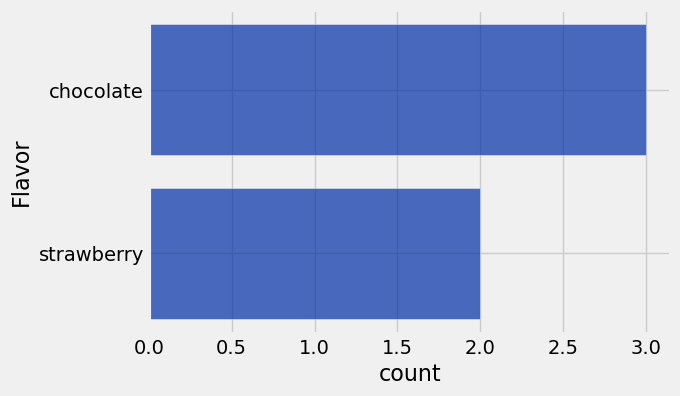

In [49]:
cones1.barh("Flavor")

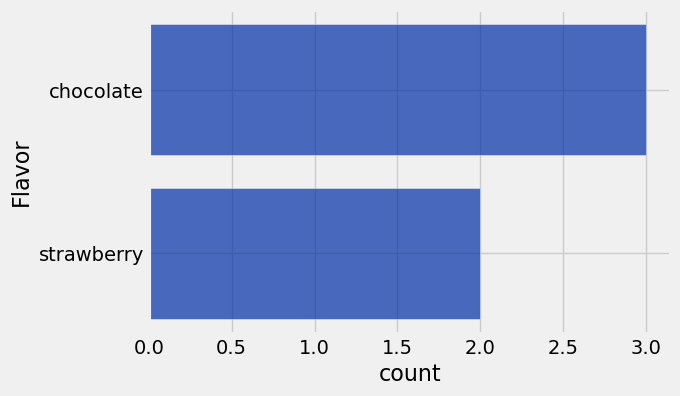

In [50]:
cones1.sort('count', descending=True).barh('Flavor')

In [34]:
cones.group('Flavor', sum)

Flavor,Price sum
chocolate,16.55
strawberry,8.8


In [51]:
cones.group('Flavor', np.average)

Flavor,Price average
chocolate,5.51667
strawberry,4.4


In [52]:
cones.group('Flavor', np.min)

Flavor,Price min
chocolate,4.75
strawberry,3.55


## Grouping by Two Columns
The group method also allows us to classify individuals according to multiple variables. This is called cross-classifying.
The table more_cones records the flavor, color, and price of six ice cream cones.

In [53]:
more_cones = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate', 'bubblegum'),
    'Color', make_array('pink', 'light brown', 'dark brown', 'pink', 'dark brown', 'pink'),
    'Price', make_array(3.55, 4.75, 5.25, 5.25, 5.25, 4.75)
)

more_cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [54]:
more_cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


In [55]:
more_cones.group('Flavor', list)

Flavor,Color list,Price list
bubblegum,['pink'],[4.75]
chocolate,"['light brown', 'dark brown', 'dark brown']","[4.75, 5.25, 5.25]"
strawberry,"['pink', 'pink']","[3.5499999999999998, 5.25]"


In [38]:
more_cones1= more_cones.group('Flavor')
more_cones1

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


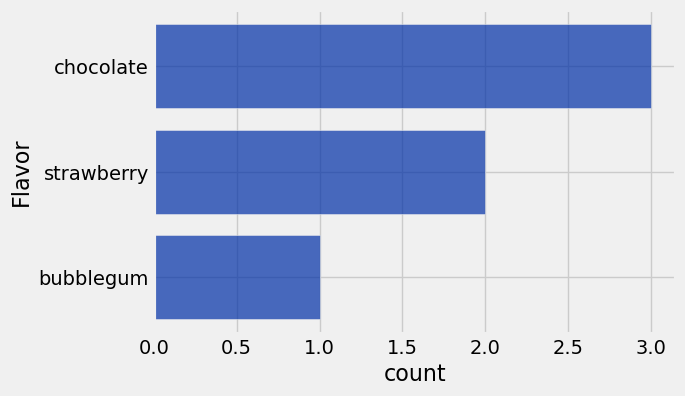

In [54]:
more_cones1.sort('count', descending=True).barh('Flavor')


In [56]:
more_cones.group(['Flavor', 'Color'])

Flavor,Color,count
bubblegum,pink,1
chocolate,dark brown,2
chocolate,light brown,1
strawberry,pink,2


A second argument aggregates all other columns that are not in the list of grouped columns.

In [57]:
more_cones.group(['Flavor', 'Color'], sum)

Flavor,Color,Price sum
bubblegum,pink,4.75
chocolate,dark brown,10.5
chocolate,light brown,4.75
strawberry,pink,8.8


## Pivot Tables: Rearranging the Output of group

It is possible to display the results of the classification in a different kind of table, called a pivot table.

### Cross-classifies according to two categorical variables
### Produces a grid of counts or aggregated values

#### Two required arguments:

First: variable that forms column labels of the grid

Second: variable that forms row labels of the grid

#### Two optional arguments (include both or neither)

values=’column_label_to_aggregate’

collect=function_to_aggregate_with


#### table.pivot(col1, col2, values, collect) 

#### table.pivot(col1, col2)


A pivot table where each unique value in col1 has its own column and each unique value in col2 has its own row. Count or aggregate values from a third column, collect with some function. 
Default values and collect return counts in cells.

In [40]:
more_cones.group(['Flavor', 'Color'])

Flavor,Color,count
bubblegum,pink,1
chocolate,dark brown,2
chocolate,light brown,1
strawberry,pink,2


In [58]:
more_cones.pivot('Flavor', 'Color')

Color,bubblegum,chocolate,strawberry
dark brown,0,2,0
light brown,0,1,0
pink,1,0,2


In [47]:
more_cones.pivot('Flavor', 'Color', values='Price', collect=sum)

Color,bubblegum,chocolate,strawberry
dark brown,0,10.5,0
light brown,0,4.75,0
pink,4.75,0,8.8


# Joining Tables by Columns


In general, a call to join that augments a table (say table1) with information from another table (say table2) looks like this:


### tblA.join(colA, tblB, colB) tblA.join(colA, tblB)

Generate a table with the columns of tblA and tblB, containing rows for all values of a column that appear in both tables. Default colB is colA. 

colA and colB must be strings specifying column names.


In [59]:
drinks = Table(['Drink', 'Cafe', 'Price'])

In [60]:
drinks = drinks.with_rows([
    ['Milk Tea', 'Asha', 5.5],
    ['Espresso', 'Strada',  1.75],
    ['Latte',    'Strada',  3.25],
    ['Espresso', "FSM",   2]
])
drinks

Drink,Cafe,Price
Milk Tea,Asha,5.5
Espresso,Strada,1.75
Latte,Strada,3.25
Espresso,FSM,2


In [52]:
discounts = Table().with_columns(
    'Coupon % off', make_array(10, 25, 5),
    'Location', make_array('Asha', 'Strada', 'Asha')
)
discounts

Coupon % off,Location
10,Asha
25,Strada
5,Asha


In [53]:
combined = drinks.join('Cafe', discounts, 'Location')
combined

Cafe,Drink,Price,Coupon % off
Asha,Milk Tea,5.5,10
Asha,Milk Tea,5.5,5
Strada,Espresso,1.75,25
Strada,Latte,3.25,25


In [54]:
discounted_frac = 1 - combined.column('Coupon % off') / 100
combined.with_column(
    'Discounted Price', 
    combined.column('Price') * discounted_frac
)

Cafe,Drink,Price,Coupon % off,Discounted Price
Asha,Milk Tea,5.5,10,4.95
Asha,Milk Tea,5.5,5,5.225
Strada,Espresso,1.75,25,1.3125
Strada,Latte,3.25,25,2.4375


# Group or Pivot?

## Distribution of one categorical variable => .group()
## Cross-classification of two or more categorical variables:
1) One row per combination => .group()
2) One variable vertically, one horizontally => .pivot()